In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import pickle


current_dir = '/home/marian/CIGAR_ANALYSIS/CIGAR/notebooks'

# Build the absolute path to ../functions
functions_path = os.path.abspath(os.path.join(current_dir, '../functions'))

# Add it to sys.path
sys.path.append(functions_path)

import parse_data 
import cigar as cig

from tqdm import tqdm


In [33]:
colors = ['royalblue', 'crimson', 'black', 'green', 'darkorange', 'brown', 'coral', 'indigo', 'magenta', 'blue']


In [34]:


font_size = 20
# Configure matplotlib to use Computer Modern fonts and mathtext
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = font_size
     


##  Mean waveform

In [35]:
base    = f"/home/marian/CIGAR_ANALYSIS/CIGAR/data"

In [36]:

runs = {8.5: f'Run{120}',
        7.5: f'Run{123}',
        6.5: f'Run{127}',
        5.5: f'Run{132}'
        }


In [37]:
a, b, c, d = enumerate(runs.items())

In [38]:
a, b, c, d 

((0, (8.5, 'Run120')),
 (1, (7.5, 'Run123')),
 (2, (6.5, 'Run127')),
 (3, (5.5, 'Run132')))

In [39]:
ii, (jj, kk)  = a

In [40]:
kk

'Run120'

In [41]:
def compare_mean_waveforms(runs_dict, channels_to_show=None, invert=True, show_difference=False, logscale = True):
    """
    Compare mean waveforms from multiple runs
    
    Parameters:
    -----------
    runs_dict : dict
        Dictionary mapping labels (e.g., pressures) to run identifiers
        Example: {8.5: 'Run120', 7.5: 'Run123', 6.5: 'Run127'}
        or {8.5: 120, 7.5: 123, 6.5: 127}
    channels_to_show : list or None
        List of channel indices to plot. If None, plots all channels.
        Example: [0, 1] to show first two channels
    invert : bool
        If True, inverts the waveforms (multiply by -1)
    show_difference : bool
        If True and only 2 runs provided, plots the difference between them
    """
    # Convert run numbers to run names if needed
    runs_formatted = {}
    for label, run in runs_dict.items():
        if isinstance(run, int):
            runs_formatted[label] = f'Run{run}'
        else:
            runs_formatted[label] = run
    
    # Load data from all runs
    all_data = {}
    for label, run_name in runs_formatted.items():
        all_data[label] = np.load(f'{base}/mean_waveforms/mean_waveforms_{run_name}.npz', allow_pickle=True)
    
    # Get channels and time from first run
    first_label = list(runs_formatted.keys())[0]
    channels = all_data[first_label]['channels']
    time = all_data[first_label]['time']
    time_window = all_data[first_label]['time_window']
    
    # Determine which channels to plot
    if channels_to_show is None:
        channels_to_show = list(range(len(channels)))
    
    # Create subplots
    n_plots = len(channels_to_show)
    if n_plots > 1:
        fig, axs = plt.subplots(n_plots, 1, figsize=(16, n_plots*6), dpi=150, sharex=True)
        run_labels = ', '.join([f'{label} bar' for label in runs_formatted.keys()])
        axs[0].set_title(f'Comparison: {run_labels}')
    else:
        fig, ax = plt.subplots(1, 1, figsize=(16, 6), dpi=150)
        run_labels = ', '.join([f'{label} bar' for label in runs_formatted.keys()])
        ax.set_title(f'Comparison: {run_labels}')
    
    # Plot each channel
    for plot_idx, ch_idx in enumerate(channels_to_show):
        if n_plots > 1:
            ax = axs[plot_idx]
        
        # Store all waveforms for y-limit calculation
        all_waveforms = []
        
        # Plot waveform for each run
        for ii, (label, run_name) in enumerate(runs_formatted.items()):
            # Load mean waveform for this channel and run
            mean_waveform = all_data[label][f'ch_{channels[ch_idx]}']
            
            # Invert if requested
            if invert:
                mean_waveform = -mean_waveform
            
            all_waveforms.append(mean_waveform)
            
            # Plot the waveform
            # ax.plot(time, mean_waveform, linewidth=3, label=f'{label} bar', color = colors[ii], alpha=0.7)
            ax.plot(time, mean_waveform, linewidth=3, label=f'{label}', color = colors[ii], alpha=0.7)
        
        # Plot difference if only 2 runs and requested
        if show_difference and len(runs_formatted) == 2:
            labels = list(runs_formatted.keys())
            difference = all_waveforms[0] - all_waveforms[1]
            ax.plot(time, difference, linewidth=3, linestyle='--', 
                   label=f'Difference ({labels[0]} bar - {labels[1]} bar) ', 
                   alpha=0.4, color='red')
        
        # Calculate y limits for integration window
        y_min = min([wf.min() for wf in all_waveforms])
        y_max = max([wf.max() for wf in all_waveforms])*1.2
        
        # Add integration window shading
        ax.fill_between(time[time_window], 
                       y_min, 
                       y_max, 
                       color='gray', alpha=0.15, label='integration window')
        
        # Add horizontal line at zero for reference
        ax.axhline(y=0, color='k', linestyle=':', alpha=0.3)
        
        ax.set_ylabel(f'ADC {channels[ch_idx]} [mV]')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best')
        if invert & logscale:
            y_min = min([wf[-1].min() for wf in all_waveforms])*0.5 # we zoom to include all the waveform
            ax.set_yscale('log')
        
            ax.set_ylim(y_min, y_max)
    
    if n_plots > 1:
        axs[-1].set_xlabel('Time (s)')
    else:
        ax.set_xlabel('Time (s)')
    
    plt.tight_layout()
    plt.show()



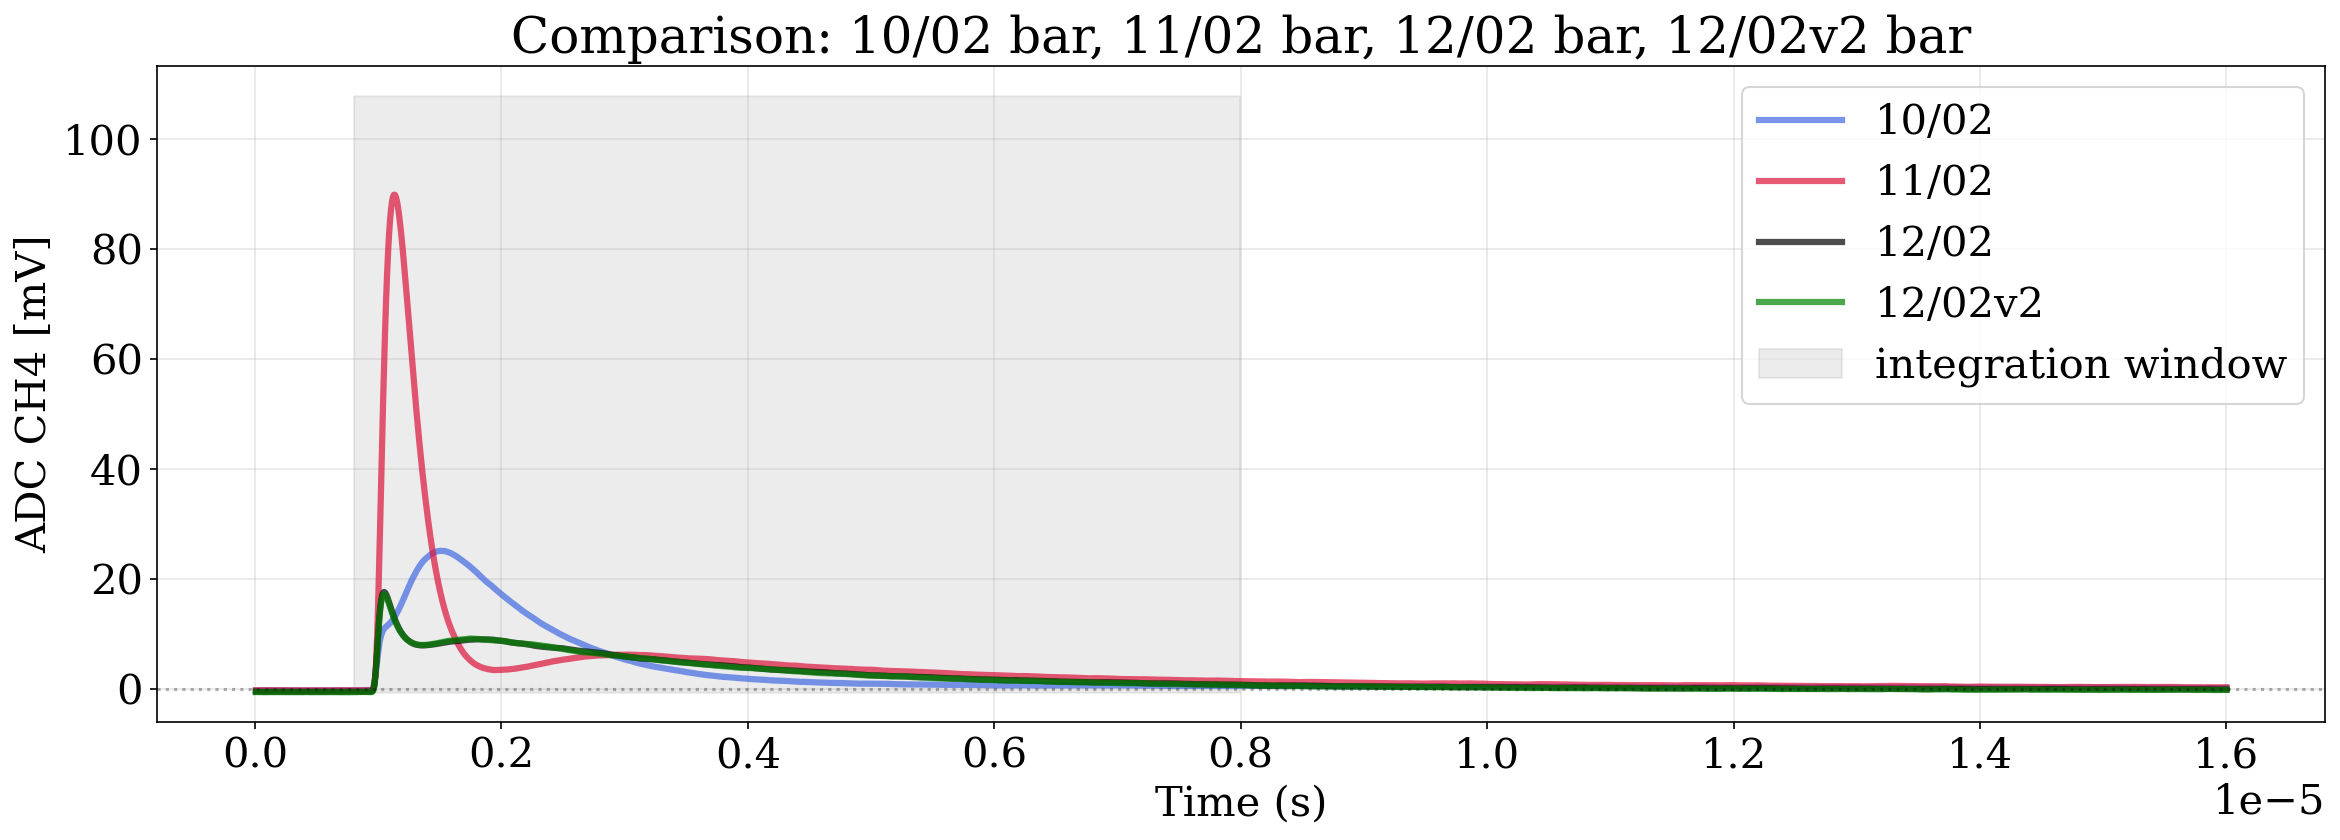

In [ ]:

# # Plot only CH1 (index 0), inverted, no difference
# compare_mean_waveforms(runs, channels_to_show=[0], invert=True, show_difference=False)

# # Plot all channels, not inverted
# compare_mean_waveforms(runs, channels_to_show=None, invert=True, show_difference=False, logscale = True)

# With only 2 runs, you can show difference
runs_2 = {'10/02': 132
          , '11/02': 133
          , '12/02': 135
          , '12/02v2': 136
          }
compare_mean_waveforms(runs_2, channels_to_show=[0], invert=True, show_difference=False, logscale = False)